# <span style = 'font-family: Georgia'>Statistical Arbitrage Project </span>
***

In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
from datetime import datetime
from binance.client import Client as bnb_client
from scipy import stats

In [2]:
client = bnb_client(tld='US')

def get_binance_px(symbol,freq,start_ts = '2021-01-01',end_ts='2023-12-31'):
    data = client.get_historical_klines(symbol,freq,start_ts,end_ts)
    columns = ['open_time','open','high','low','close','volume','close_time','quote_volume',
    'num_trades','taker_base_volume','taker_quote_volume','ignore']

    data = pd.DataFrame(data,columns = columns)
    
    # Convert from POSIX timestamp (number of millisecond since jan 1, 1970)
    data['open_time'] = pd.to_datetime(data['open_time'], unit='ms', utc=True)
    data['close_time'] = pd.to_datetime(data['close_time'], unit='ms', utc=True)
    return data 

tickers = ['BTCUSDT','ETHUSDT','ADAUSDT','BNBUSDT','SOLUSDT','DOGEUSDT','ZECUSDT','XLMUSDT','LINKUSDT',
           'LTCUSDT','AVAXUSDT','SHIBUSDT']
          

freq = '1d'
px = {}
for x in tickers:
    data = get_binance_px(x,freq)
    px[x] = data.set_index('open_time')['close']

px = pd.DataFrame(px).astype(float)
px = px.reindex(pd.date_range(px.index[0],px.index[-1],freq=freq))
px

,BTCUSDT,ETHUSDT,ADAUSDT,BNBUSDT,SOLUSDT,DOGEUSDT,ZECUSDT,XLMUSDT,LINKUSDT,LTCUSDT,AVAXUSDT,SHIBUSDT
2021-01-01 00:00:00+00:00,29305.29,728.52,0.17488,37.6696,1.8455,0.005613,NaN,0.13170,NaN,126.19,NaN,NaN
2021-01-02 00:00:00+00:00,32162.01,774.56,0.17726,38.2207,1.7955,0.010585,NaN,0.12758,NaN,136.99,NaN,NaN
2021-01-03 00:00:00+00:00,33031.74,978.14,0.20624,41.1282,2.1682,0.009832,NaN,0.13634,NaN,160.86,NaN,NaN
2021-01-04 00:00:00+00:00,32005.27,1042.10,0.22533,41.0884,2.4924,0.009692,NaN,0.16407,NaN,155.55,NaN,NaN
2021-01-05 00:00:00+00:00,33946.09,1100.22,0.25913,41.8000,2.1561,0.009966,NaN,0.19408,NaN,158.13,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-27 00:00:00+00:00,43410.09,2372.18,0.63350,323.3000,106.9700,0.093520,31.88,0.13090,16.710,75.96,42.35,0.000011
2023-12-28 00:00:00+00:00,42601.54,2339.83,0.61910,323.1000,101.9100,0.091690,31.52,0.13180,16.022,76.62,39.87,0.000011
2023-12-29 00:00:00+00:00,42085.42,2298.84,0.60570,313.3000,106.1800,0.090940,28.43,0.12970,15.531,73.20,40.10,0.000010
2023-12-30 00:00:00+00:00,42138.01,2293.40,0.60140,316.8000,101.7700,0.090090,28.20,0.13260,15.200,73.31,39.27,0.000010


,BTCUSDT,ETHUSDT,ADAUSDT,BNBUSDT,SOLUSDT,DOGEUSDT,ZECUSDT,XLMUSDT,LINKUSDT,LTCUSDT,AVAXUSDT,SHIBUSDT
2022-01-15 00:00:00+00:00,0.000008,0.006127,0.000914,0.009012,0.010515,0.006657,0.018233,-0.020899,-0.022110,0.022693,0.030468,0.002599
2022-01-16 00:00:00+00:00,-0.000131,0.005714,0.091464,0.007272,0.000805,-0.042841,-0.026860,-0.000347,0.013883,-0.009065,-0.009676,-0.012638
2022-01-17 00:00:00+00:00,-0.020086,-0.040123,0.136679,-0.045671,-0.054484,-0.032409,-0.019816,-0.009962,-0.069640,0.032906,-0.059603,-0.054808
2022-01-18 00:00:00+00:00,0.003707,-0.015560,-0.089473,-0.008322,0.010349,-0.034572,-0.051264,-0.008658,-0.035744,-0.064309,-0.005888,-0.025000
2022-01-19 00:00:00+00:00,-0.016550,-0.024918,-0.084579,-0.020466,-0.040919,-0.018679,-0.028919,-0.034700,-0.053205,-0.037579,-0.041807,-0.029558
...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-27 00:00:00+00:00,0.020781,0.062638,0.042627,0.084535,-0.050337,0.024652,0.051105,0.042197,0.107282,0.041261,-0.047673,0.029273
2023-12-28 00:00:00+00:00,-0.018626,-0.013637,-0.022731,-0.000619,-0.047303,-0.019568,-0.011292,0.006875,-0.041173,0.008689,-0.058560,-0.024771
2023-12-29 00:00:00+00:00,-0.012115,-0.017518,-0.021644,-0.030331,0.041900,-0.008180,-0.098033,-0.015933,-0.030645,-0.044636,0.005769,-0.020696
2023-12-30 00:00:00+00:00,0.001250,-0.002366,-0.007099,0.011171,-0.041533,-0.009347,-0.008090,0.022359,-0.021312,0.001503,-0.020698,0.006724


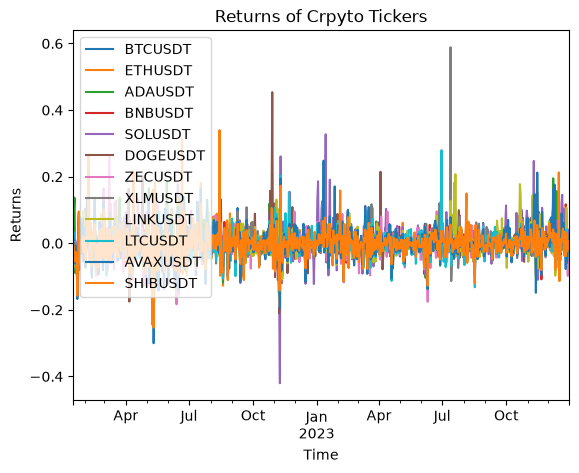

In [3]:
# Returns
ret = px / px.shift() -1
ret = ret.dropna()
ret
ret.plot(title = 'Returns of Crpyto Tickers', ylabel = 'Returns', xlabel = 'Time') 
ret

# <span style = 'font-family: Georgia'> Twenty-Day Rolling Momentum Strategy </span>
***

In [4]:
# Momentum Signal

# Because momentum is more prevelant in the longer term we will do in the past 30 days

# Momentum for First Strategy
momentum1 = ret.rolling(20,min_periods =1).mean()
momentum1 = momentum1.dropna()

# Signal Ranked for First Strategy
momrank1 = momentum1.rank(axis = 1)


# Signal Demeaned as it is a XS strategy

ranked1 = momentum1.rank(axis = 1)

demeaned1 = ranked1.sub(ranked1.mean(axis=1), axis=0)

# Then we normalize for the abs of weights to equal 1 

normw1 = demeaned1.div(demeaned1.abs().sum(axis=1), axis=0)
normw1



,BTCUSDT,ETHUSDT,ADAUSDT,BNBUSDT,SOLUSDT,DOGEUSDT,ZECUSDT,XLMUSDT,LINKUSDT,LTCUSDT,AVAXUSDT,SHIBUSDT
2022-01-15 00:00:00+00:00,-0.097222,-0.013889,-0.069444,0.041667,0.069444,0.013889,0.097222,-0.125000,-0.152778,0.125000,0.152778,-0.041667
2022-01-16 00:00:00+00:00,-0.013889,0.041667,0.152778,0.097222,0.013889,-0.152778,-0.069444,-0.125000,-0.041667,0.069444,0.125000,-0.097222
2022-01-17 00:00:00+00:00,0.097222,0.069444,0.152778,0.013889,-0.069444,-0.125000,0.041667,-0.013889,-0.152778,0.125000,-0.041667,-0.097222
2022-01-18 00:00:00+00:00,0.125000,-0.013889,0.152778,0.041667,0.069444,-0.125000,-0.069444,0.013889,-0.152778,0.097222,-0.041667,-0.097222
2022-01-19 00:00:00+00:00,0.125000,0.041667,0.152778,0.069444,0.013889,-0.125000,-0.069444,-0.013889,-0.152778,0.097222,-0.041667,-0.097222
...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-27 00:00:00+00:00,-0.125000,-0.097222,0.097222,0.069444,0.125000,-0.152778,-0.069444,-0.013889,0.013889,-0.041667,0.152778,0.041667
2023-12-28 00:00:00+00:00,-0.069444,-0.013889,0.069444,0.125000,0.152778,-0.152778,-0.125000,0.013889,-0.097222,-0.041667,0.097222,0.041667
2023-12-29 00:00:00+00:00,-0.069444,0.013889,0.041667,0.125000,0.152778,-0.125000,-0.152778,-0.041667,-0.013889,-0.097222,0.097222,0.069444
2023-12-30 00:00:00+00:00,-0.041667,-0.013889,0.041667,0.125000,0.152778,-0.125000,-0.152778,0.013889,-0.097222,-0.069444,0.097222,0.069444


In [5]:
# Unconstrained Backtest

# Portfolio Returns for First Strategy

portret1 = (normw1 *ret.shift(-1)).sum(axis = 1)


<Axes: >

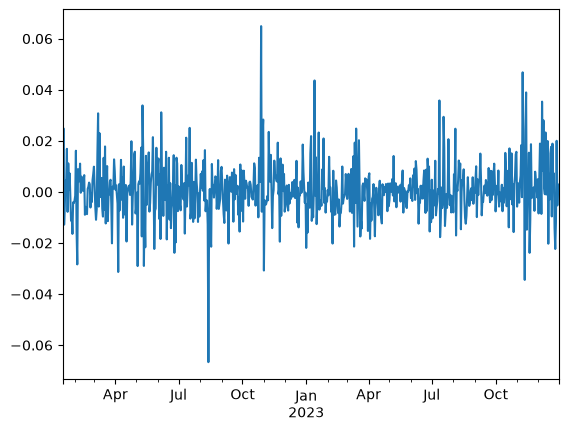

In [6]:
# First Strategies, return plot

portret1.plot()

In [7]:
# Annualized Stats
ret1 = float(portret1.mean() * 365)
vol1 = float(portret1.std() * np.sqrt(365)) # The crypto market is opened 365 times a year unlike the stock market which is only 252 days
sr1 = ret1 / vol1

stats1 = pd.Series([ret1, vol1, sr1],index=["Ann_ret", "Ann_vol", "Ann_sharpe"])
stats1 = stats1.rename_axis("Annualized Statistics for Twenty-Day Rolling Momentum Strategy")

stats1

Annualized Statistics for Twenty-Day Rolling Momentum Strategy
Ann_ret       0.239537
Ann_vol       0.205959
Ann_sharpe    1.163037
dtype: float64

# <span style= 'font-family: "Georgia"' > Monmentum Seasonalitt Strategy </span>
***

In [8]:
# Finding the average returns per month in a 3 year period
# Second Strategy

retmmean = ret.groupby(ret.index.month).mean()
retmmean

,BTCUSDT,ETHUSDT,ADAUSDT,BNBUSDT,SOLUSDT,DOGEUSDT,ZECUSDT,XLMUSDT,LINKUSDT,LTCUSDT,AVAXUSDT,SHIBUSDT
1,0.005025,0.002208,0.006548,-0.000041,0.013563,0.001800,-0.003800,-0.000354,-0.002656,0.000985,0.009306,0.001274
2,0.002713,0.002455,-0.002590,0.000917,0.000050,-0.003535,0.004398,-0.000201,-0.000735,0.001522,0.002214,0.005443
3,0.004766,0.004466,0.005617,0.002439,0.003607,0.000391,0.006883,0.007030,0.003464,0.001550,0.003820,-0.000969
4,-0.002447,-0.002267,-0.006360,-0.000722,-0.004074,0.000935,-0.006778,-0.007264,-0.007858,-0.003999,-0.008778,-0.004544
5,-0.003358,-0.004654,-0.001921,-0.003283,-0.009265,-0.006919,-0.004044,-0.001352,-0.005663,-0.003681,-0.012821,-0.009043
6,-0.005142,-0.008221,-0.008395,-0.009604,-0.004709,-0.004078,-0.006599,-0.000960,-0.001878,0.000957,-0.006812,-0.002343
7,0.002145,0.007464,0.003967,0.004649,0.008598,0.003529,0.002269,0.008704,0.007267,-0.000262,0.006330,0.004305
8,-0.004035,-0.002536,-0.004937,-0.001704,-0.007089,-0.004132,-0.003701,-0.005869,-0.005730,-0.007092,-0.006868,0.001363
9,0.000419,-0.001902,-0.000192,0.000312,0.002824,-0.000082,0.000684,0.001733,0.008510,0.001062,-0.002530,-0.002150
10,0.005109,0.004360,0.001593,0.003233,0.009962,0.015130,-0.000294,0.001075,0.006672,0.001416,0.005600,0.003030


In [9]:
from scipy import stats
zscores = stats.zscore(retmmean)
zscoresdf = pd.DataFrame(zscores, index =retmmean.index, columns = retmmean.columns)

zscoresdf

,BTCUSDT,ETHUSDT,ADAUSDT,BNBUSDT,SOLUSDT,DOGEUSDT,ZECUSDT,XLMUSDT,LINKUSDT,LTCUSDT,AVAXUSDT,SHIBUSDT
1,1.303950,0.486139,1.442348,0.029431,1.801461,0.316526,-0.620293,-0.029904,-0.526868,0.303111,1.253188,0.417411
2,0.642248,0.545076,-0.534387,0.299604,-0.191644,-0.643391,1.397409,0.004691,-0.178478,0.456652,0.265758,1.483751
3,1.229951,1.025538,1.240872,0.729401,0.332981,0.063069,2.008906,1.645973,0.583068,0.464778,0.489399,-0.156215
4,-0.835031,-0.583206,-1.349712,-0.162964,-0.799873,0.160879,-1.353311,-1.598104,-1.470373,-1.121712,-1.264519,-1.070535
5,-1.095775,-1.153388,-0.389698,-0.885784,-1.565545,-1.252299,-0.680501,-0.256526,-1.072142,-1.030568,-1.827487,-2.221397
6,-1.606588,-2.005581,-1.789891,-2.670117,-0.893584,-0.741096,-1.309392,-0.167552,-0.385713,0.295196,-0.990911,-0.507720
7,0.479524,1.741794,0.884097,1.353176,1.069214,0.627740,0.873333,2.025771,1.272693,-0.053280,0.838853,1.192886
8,-1.289534,-0.647298,-1.042057,-0.440237,-1.244512,-0.750720,-0.596060,-1.281557,-1.084301,-2.005824,-0.998614,0.440390
9,-0.014563,-0.495931,-0.015666,0.128988,0.217576,-0.022073,0.483360,0.443719,1.498173,0.325204,-0.394751,-0.458324
10,1.327977,1.000297,0.370536,0.953652,1.270388,2.715045,0.242635,0.294346,1.164821,0.426326,0.737122,0.866769


In [10]:
filtered_returns2 = retmmean.mask(zscoresdf > 1.5).mask(zscoresdf < -1.5)

ranked_returns2 = filtered_returns2.rank(axis = 0)
centered_rank2 = ranked_returns2.rank(axis=0) -ranked_returns2.rank(axis=0).mean()

weight2 = centered_rank2.div(centered_rank2.abs().sum(axis=1), axis=0)
weight2

,BTCUSDT,ETHUSDT,ADAUSDT,BNBUSDT,SOLUSDT,DOGEUSDT,ZECUSDT,XLMUSDT,LINKUSDT,LTCUSDT,AVAXUSDT,SHIBUSDT
1,0.163265,0.061224,0.204082,-0.040816,NaN,0.122449,-0.081633,0.040816,-0.061224,0.020408,0.204082,0.000000
2,0.074074,0.092593,-0.111111,0.037037,-0.018519,-0.037037,0.185185,0.074074,0.018519,0.129630,-0.037037,0.185185
3,0.125000,0.187500,0.166667,0.125000,0.062500,0.041667,NaN,NaN,0.062500,0.187500,0.000000,-0.041667
4,-0.069767,-0.058140,-0.116279,-0.069767,-0.058140,0.046512,-0.116279,NaN,-0.127907,-0.104651,-0.116279,-0.116279
5,-0.126984,-0.142857,-0.063492,-0.158730,NaN,-0.158730,-0.095238,-0.031746,-0.111111,-0.111111,NaN,NaN
6,NaN,NaN,NaN,NaN,-0.212121,-0.121212,-0.242424,0.000000,-0.030303,-0.030303,-0.181818,-0.181818
7,0.030769,NaN,0.061538,0.153846,0.107692,0.153846,0.123077,NaN,0.138462,-0.046154,0.061538,0.123077
8,-0.129870,-0.090909,-0.103896,-0.103896,-0.116883,-0.077922,-0.025974,-0.103896,-0.116883,NaN,-0.103896,0.025974
9,-0.045455,-0.068182,-0.045455,0.000000,0.022727,0.000000,0.136364,0.181818,0.250000,0.068182,-0.090909,-0.090909
10,0.151515,0.106061,0.030303,0.121212,0.136364,NaN,0.060606,0.090909,0.106061,0.075758,0.030303,0.090909


In [11]:
month_weights = weight2.loc[ret.index.month]  # align weights by month
month_weights.index = ret.index              # restore datetime index

portret2 = (month_weights * ret).sum(axis=1).dropna()
portret2

2022-01-15 00:00:00+00:00    0.006704
2022-01-16 00:00:00+00:00    0.012621
2022-01-17 00:00:00+00:00    0.014036
2022-01-18 00:00:00+00:00   -0.018995
2022-01-19 00:00:00+00:00   -0.028038
                               ...   
2023-12-27 00:00:00+00:00   -0.019363
2023-12-28 00:00:00+00:00   -0.013302
2023-12-29 00:00:00+00:00    0.008195
2023-12-30 00:00:00+00:00   -0.005245
2023-12-31 00:00:00+00:00   -0.001182
Freq: D, Length: 716, dtype: float64

<Axes: >

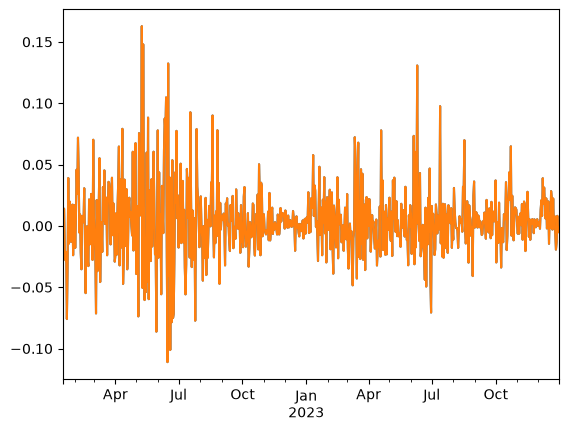

In [12]:
# Portfolio Returns Plotted

portret2.plot()

portret2.plot()

In [13]:
# Annualized Statistics

ret2 = float(portret2.mean() * 365)
vol2 = float(portret2.std() * np.sqrt(365))
sr2 = ret2 / vol2

stats2 = pd.Series([ret2, vol2, sr2],index=["Ann_ret", "Ann_vol", "Ann_sharpe"])
stats2 = stats2.rename_axis("Annualized Statistics for Seasonality Momentum Strategy")

stats2

Annualized Statistics for Seasonality Momentum Strategy
Ann_ret       1.494246
Ann_vol       0.547706
Ann_sharpe    2.728189
dtype: float64

# Vix Macro Correlation with Reversal Strategy
***

In [14]:
# Third Strategy

rankedreverse3 = ret.rank(axis = 1) - (ret.rank(axis = 1).mean(axis = 1).mean())
rankedreverse3.dropna()
normalized_weights3 = rankedreverse3 / float(rankedreverse3.abs().sum(axis = 1).mean().mean())
normalized_weights3 = normalized_weights3 * -1
normalized_weights3

,BTCUSDT,ETHUSDT,ADAUSDT,BNBUSDT,SOLUSDT,DOGEUSDT,ZECUSDT,XLMUSDT,LINKUSDT,LTCUSDT,AVAXUSDT,SHIBUSDT
2022-01-15 00:00:00+00:00,0.097222,0.013889,0.069444,-0.041667,-0.069444,-0.013889,-0.097222,0.125000,0.152778,-0.125000,-0.152778,0.041667
2022-01-16 00:00:00+00:00,-0.013889,-0.069444,-0.152778,-0.097222,-0.041667,0.152778,0.125000,0.013889,-0.125000,0.041667,0.069444,0.097222
2022-01-17 00:00:00+00:00,-0.041667,0.013889,-0.152778,0.041667,0.069444,-0.013889,-0.069444,-0.097222,0.152778,-0.125000,0.125000,0.097222
2022-01-18 00:00:00+00:00,-0.125000,-0.013889,0.152778,-0.069444,-0.152778,0.041667,0.097222,-0.041667,0.069444,0.125000,-0.097222,0.013889
2022-01-19 00:00:00+00:00,-0.152778,-0.069444,0.152778,-0.097222,0.069444,-0.125000,-0.041667,0.013889,0.125000,0.041667,0.097222,-0.013889
...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-27 00:00:00+00:00,0.097222,-0.097222,-0.041667,-0.125000,0.152778,0.069444,-0.069444,-0.013889,-0.152778,0.013889,0.125000,0.041667
2023-12-28 00:00:00+00:00,-0.013889,-0.041667,0.041667,-0.097222,0.125000,0.013889,-0.069444,-0.125000,0.097222,-0.152778,0.152778,0.069444
2023-12-29 00:00:00+00:00,-0.069444,-0.013889,0.041667,0.069444,-0.152778,-0.097222,0.152778,-0.041667,0.097222,0.125000,-0.125000,0.013889
2023-12-30 00:00:00+00:00,-0.041667,-0.013889,0.013889,-0.125000,0.152778,0.069444,0.041667,-0.152778,0.125000,-0.069444,0.097222,-0.097222


##### Because in reversal we want to take the opposite weights of a momenutm strategy we are going to multiply our weights by a negative 1

In [15]:
indv_portret_3 = normalized_weights3.shift(1) * ret
indv_portret_3.index = pd.to_datetime(indv_portret_3.index).tz_localize(None).normalize()

portret3 =indv_portret_3.sum(axis = 1, min_count = 1)
portret3.name = ('Portfolio Returns')
portret3

2022-01-15         NaN
2022-01-16    0.013428
2022-01-17   -0.018064
2022-01-18    0.017964
2022-01-19   -0.009717
                ...   
2023-12-27   -0.031797
2023-12-28   -0.009299
2023-12-29    0.020153
2023-12-30    0.006309
2023-12-31    0.001674
Freq: D, Name: Portfolio Returns, Length: 716, dtype: float64

In [16]:
ret3 = float(portret3.mean() * 365)
vol3 = float(portret3.std() * np.sqrt(365))
sr3 = ret3 / vol3

stats3 = pd.Series([ret3, vol3, sr3],index=["Ann_ret", "Ann_vol", "Ann_sharpe"])
stats3 = stats3.rename_axis("Annualized Statistics for Reversal Strategy")
stats3

Annualized Statistics for Reversal Strategy
Ann_ret       0.094337
Ann_vol       0.212693
Ann_sharpe    0.443534
dtype: float64

# Strategy Statistics Before Weighting and Finished Backtest
***

In [17]:
returns = {'Twenty Day Momentum': ret1, 'Monthly Weighted Momentum': ret2, 'Reversal Strategy': ret3}
volatility = {'Twenty Day Momentum': vol1, 'Monthly Weighted Momentum': vol2, 'Reversal Strategy': vol3}
sharpes = {'Twenty Day Momentum': sr1, 'Monthly Weighted Momentum': sr2, 'Reversal Strategy': sr3}

In [18]:
stats_before = pd.DataFrame({'Returns': returns, 'Volatility': volatility, 'Sharpe': sharpes})
stats_before

,Returns,Volatility,Sharpe
Twenty Day Momentum,0.239537,0.205959,1.163037
Monthly Weighted Momentum,1.494246,0.547706,2.728189
Reversal Strategy,0.094337,0.212693,0.443534


## Weighting

In [19]:
def sr_weights(sigma,mu): # Using sharpe ratio proportional weights
    wgt = mu / np.diag(sigma) 
    wgt = wgt / np.abs(wgt).sum()
    return wgt

In [20]:
p1 = portret1.copy()
p2 = portret2.copy()
p3 = portret3.copy()

for p in [p1, p2, p3]:
    p.index = pd.to_datetime(p.index, utc=True).tz_localize(None).normalize() # Utilized AI for this code, was stuck on timezone bug

portfolio_returns = pd.concat(
    [p1, p2, p3],
    axis=1,
    keys=["Twenty Day Momentum", "Monthly Weighted Momentum", "Reversal Strategy"]
)

sigma = portfolio_returns.cov() # Generating historical covariance matrix
sigma

,Twenty Day Momentum,Monthly Weighted Momentum,Reversal Strategy
Twenty Day Momentum,0.000116,-1.883329e-05,6.770647e-06
Monthly Weighted Momentum,-0.000019,8.218693e-04,-2.705538e-07
Reversal Strategy,0.000007,-2.705538e-07,1.239402e-04


In [21]:
corr = portfolio_returns.corr() # Sort of a normalized version of the covariance matrix
corr

,Twenty Day Momentum,Monthly Weighted Momentum,Reversal Strategy
Twenty Day Momentum,1.000000,-0.060938,0.056443
Monthly Weighted Momentum,-0.060938,1.000000,-0.000847
Reversal Strategy,0.056443,-0.000847,1.000000


In [22]:
mu = portfolio_returns.mean()
mu

Twenty Day Momentum          0.000656
Monthly Weighted Momentum    0.004094
Reversal Strategy            0.000258
dtype: float64

In [23]:
weights = {}

# Going to use sharpe ratio proportional weights 
weights['sr'] = sr_weights(sigma,mu)
weights = pd.DataFrame([sr_weights(sigma, mu)], index=["Weight"], columns = portfolio_returns.columns)
weights

,Twenty Day Momentum,Monthly Weighted Momentum,Reversal Strategy
Weight,0.444173,0.391801,0.164026


In [24]:
#  Take the dot product of the portfolio returns and the weights of the strategies to get the sharpe

combo_rets = portfolio_returns @ weights.loc["Weight"] 
combo_sr = (combo_rets.mean() / combo_rets.std() * np.sqrt(365))
float(combo_sr)

3.0652746974108314

### The weighted Sharpe is 3.065 this is before execution and checking for overfit

# Execution

In [25]:
strategy_weights = pd.Series(sr_weights(sigma, mu),index=portfolio_returns.columns)

w1 = normw1.copy()
w2 = month_weights.copy()
w3 = normalized_weights3.copy()  


for w in [w1, w2, w3]:
    w.index = (pd.to_datetime(w.index, utc=True).tz_localize(None).normalize())

common_index = w1.index.intersection(w2.index).intersection(w3.index) # This finds the dates that exist in all three strategy weight DataFrames

w1 = w1.reindex(common_index).fillna(0) # Reindex to make sure all three strategies are lined up
w2 = w2.reindex(common_index).fillna(0)
w3 = w3.reindex(common_index).fillna(0)

combined_asset_weights = (strategy_weights["Twenty Day Momentum"] * w1 + strategy_weights["Monthly Weighted Momentum"] * w2 + strategy_weights["Reversal Strategy"] * w3)

In [26]:
turnover = (combined_asset_weights.fillna(0) - combined_asset_weights.shift().fillna(0)).abs().sum(1)
turnover

2022-01-15    0.460981
2022-01-16    0.276357
2022-01-17    0.238779
2022-01-18    0.269182
2022-01-19    0.152252
                ...   
2023-12-27    0.119592
2023-12-28    0.190959
2023-12-29    0.258942
2023-12-30    0.274505
2023-12-31    0.323858
Freq: D, Length: 716, dtype: float64

In [27]:
# Average Turnover
turnover_mean = float(turnover.mean()) # Very Low Turnover as we are trading daily
turnover_mean

0.24862016216735075

<Axes: >

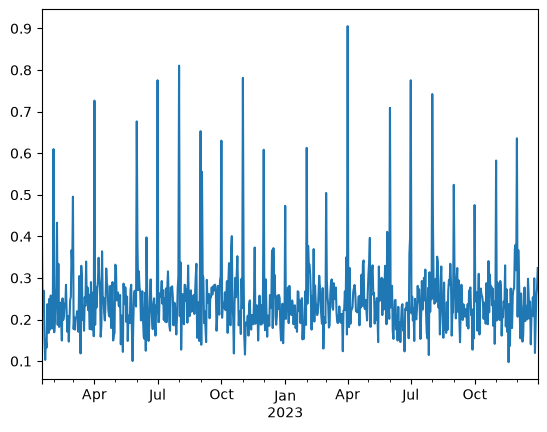

In [28]:
turnover.plot()

In [29]:
bspcost = 10
tcosts = bspcost * turnover * 10**-4 # For basis points you multiply 10^-4 because 1 basis point is 0.0001 of a decimal return

In [37]:
net_ret = combo_rets - tcosts

2024-01-02         NaN
2024-01-03   -0.025763
2024-01-04    0.012657
2024-01-05   -0.006468
2024-01-06   -0.002865
                ...   
2025-12-27    0.001976
2025-12-28    0.004656
2025-12-29   -0.001653
2025-12-30    0.008822
2025-12-31   -0.001341
Freq: D, Length: 730, dtype: float64

In [31]:
net_sr = (net_ret.mean() / net_ret.std() * np.sqrt(365))
float(net_sr)

2.673829625322895

In [32]:
# Doesn't eat up too of our sharpe as we don't trade super freqeuntly, just once a day

In [ ]:
def max_drawdown(returns):
    cumulative_returns = (1 + returns.fillna(0)).cumprod()
    running_peak = cumulative_returns.cummax()
    drawdowns = cumulative_returns / running_peak - 1
    
    return drawdowns.min()

max_dd_train = max_drawdown(training_portfolio_returns)

# Overfit

In [33]:
# To test overfit, we are going to run our strategy over a holdout set

In [34]:

# Save the weights learned from the 2021-2023 training set
training_strategy_weights = strategy_weights.copy()
training_monthly_weights = weight2.copy()

client = bnb_client(tld='US')

def get_binance_px(symbol,freq,start_ts = '2024-01-01',end_ts='2025-12-31'):
    data = client.get_historical_klines(symbol,freq,start_ts,end_ts)
    columns = ['open_time','open','high','low','close','volume','close_time','quote_volume',
    'num_trades','taker_base_volume','taker_quote_volume','ignore']

    data = pd.DataFrame(data,columns = columns)
    

    data['open_time'] = pd.to_datetime(data['open_time'], unit='ms', utc=True)
    data['close_time'] = pd.to_datetime(data['close_time'], unit='ms', utc=True)
    return data 

tickers = ['BTCUSDT','ETHUSDT','ADAUSDT','BNBUSDT','SOLUSDT','DOGEUSDT','ZECUSDT','XLMUSDT','LINKUSDT',
           'LTCUSDT','AVAXUSDT','SHIBUSDT']
          

freq = '1d'
px = {}
for x in tickers:
    data = get_binance_px(x,freq)
    px[x] = data.set_index('open_time')['close']

px = pd.DataFrame(px).astype(float)
px = px.reindex(pd.date_range(px.index[0],px.index[-1],freq=freq))

# Returns
ret = px / px.shift() -1
ret = ret.dropna()

momentum1 = ret.rolling(20,min_periods =1).mean()
momentum1 = momentum1.dropna()
momrank1 = momentum1.rank(axis = 1)
ranked1 = momentum1.rank(axis = 1)
demeaned1 = ranked1.sub(ranked1.mean(axis=1), axis=0)
normw1 = demeaned1.div(demeaned1.abs().sum(axis=1), axis=0)
portret1 = (normw1 *ret.shift(-1)).sum(axis = 1)

ret1 = float(portret1.mean() * 365)
vol1 = float(portret1.std() * np.sqrt(365)) 
sr1_hold = ret1 / vol1



# Use monthly weights learned from the 2021-2023 training set
month_weights = training_monthly_weights.loc[ret.index.month] 
month_weights.index = ret.index             

portret2 = (month_weights * ret).sum(axis=1).dropna()

ret2 = float(portret2.mean() * 365)
vol2 = float(portret2.std() * np.sqrt(365))
sr2_hold = ret2 / vol2


rankedreverse3 = ret.rank(axis = 1) - (ret.rank(axis = 1).mean(axis = 1).mean())
rankedreverse3.dropna()


normalized_weights3 = rankedreverse3 / float(rankedreverse3.abs().sum(axis = 1).mean().mean())
normalized_weights3 = normalized_weights3 * -1

indv_portret_3 = normalized_weights3.shift(1) * ret
indv_portret_3.index = pd.to_datetime(indv_portret_3.index).tz_localize(None).normalize()

portret3 =indv_portret_3.sum(axis = 1, min_count = 1)
portret3.name = ('Portfolio Returns')

ret3 = float(portret3.mean() * 365)
vol3 = float(portret3.std() * np.sqrt(365))
sr3_hold = ret3 / vol3

returns = {'Twenty Day Momentum': ret1, 'Monthly Weighted Momentum': ret2, 'Reversal Strategy': ret3}
volatility = {'Twenty Day Momentum': vol1, 'Monthly Weighted Momentum': vol2, 'Reversal Strategy': vol3}
sharpes = {'Twenty Day Momentum': sr1_hold, 'Monthly Weighted Momentum': sr2_hold, 'Reversal Strategy': sr3_hold}

stats_before = pd.DataFrame({'Returns': returns, 'Volatility': volatility, 'Sharpe': sharpes})


p1 = portret1.copy()
p2 = portret2.copy()
p3 = portret3.copy()

for p in [p1, p2, p3]:
    p.index = pd.to_datetime(p.index, utc=True).tz_localize(None).normalize() # Utilized AI for this code, was stuck on timezone bug

portfolio_returns = pd.concat(
    [p1, p2, p3],
    axis=1,
    keys=["Twenty Day Momentum", "Monthly Weighted Momentum", "Reversal Strategy"]
)


# Use the strategy weights learned from the 2021-2023 training set
weights = pd.DataFrame(
    [training_strategy_weights],
    index=["Weight"],
    columns = portfolio_returns.columns
)


combo_rets = portfolio_returns @ weights.loc["Weight"] 
combo_sr = (combo_rets.mean() / combo_rets.std() * np.sqrt(365))


strategy_weights = training_strategy_weights.copy()

w1 = normw1.copy()
w2 = month_weights.copy()
w3 = normalized_weights3.copy()  

for w in [w1, w2, w3]:
    w.index = (pd.to_datetime(w.index, utc=True).tz_localize(None).normalize())

common_index = w1.index.intersection(w2.index).intersection(w3.index) 

w1 = w1.reindex(common_index).fillna(0) 
w2 = w2.reindex(common_index).fillna(0)
w3 = w3.reindex(common_index).fillna(0)

combined_asset_weights = (
    strategy_weights["Twenty Day Momentum"] * w1
    + strategy_weights["Monthly Weighted Momentum"] * w2
    + strategy_weights["Reversal Strategy"] * w3
)

turnover = (combined_asset_weights.fillna(0) - combined_asset_weights.shift().fillna(0)).abs().sum(1)

turnover_mean = float(turnover.mean()) 

bspcost = 10
tcosts = bspcost * turnover * 10**-4 

net_ret_hold = combo_rets - tcosts
net_sr_hold = (net_ret_hold.mean() / net_ret_hold.std() * np.sqrt(365))
max_dd_hold = max_drawdown(holdout_portfolio_returns)
float(net_sr_hold)


0.8506697909678314

In [35]:
comps = {'Training':  [sr1, sr2, sr3, net_sr,max_dd_train],'Holdout': [sr1_hold, sr2_hold, sr3_hold, net_sr_hold, max_dd_hold]}

comparison = pd.DataFrame(comps, index=['Momentum', 'Seasonality', 'Reversal', 'Sharpe', 'Max DD'])
comparison

,Training,Holdout
Momentum,1.163037,1.438898
Seasonality,2.728189,0.635533
Reversal,0.443534,-0.277048
Sharpe,2.673830,0.850670


In [36]:
# Seaonsality and Reversal Strategies caused overfit

# Conclusion, only using the momentum strategy can be a good trading 